In [2]:
import pandas as pd
import numpy as np
from pathlib import Path

In [13]:
path = Path('.')
list_of_years = list(range(2011,2024))
frames = []
num_fields = ['MYR', 'OL', 'OW', 'OH ', 'WB', 'CW ', 'A', 'B', 'C','D', 'E', 'F', 'G', 'TWF', 'TWR ', 'YEAR']
for i in list_of_years:
    try:
        with open(path/f'cars_database/{i}_en.csv', 'r') as f:
            df = pd.read_csv(f)
            df['YEAR']  = i
            for field in num_fields:
                df[field] = df[field].astype(float)
        df.columns = ['MAKE', 'MODEL', 'MYR', 'OL', 'OW', 'OH', 'WB', 'CW', 'A', 'B', 'C','D', 'E', 'FH', 'RH', 'TWF', 'TWR', 'WDIST', 'YEAR']
        frames.append(df)
    except:
        print(i, 'has encoding error')

df = pd.concat(frames)

2011 has encoding error
2013 has encoding error


In [14]:

df['TW'] = np.round((df.TWF+df.TWR)/2,1)

In [15]:
parameters = ['OL', 'OW', 'OH', 'WB', 'A', 'C','D', 'E', 'FH', 'RH', 'TW']
# old = ['OH', 'OW', 'WB','RH','FH','TW']
out_df = df[parameters].corr(method='pearson')
print(out_df)

          OL        OW        OH        WB         A         C         D  \
OL  1.000000  0.757568  0.758272  0.970142  0.016015  0.693736  0.633309   
OW  0.757568  1.000000  0.591285  0.733680  0.113459  0.574815  0.526766   
OH  0.758272  0.591285  1.000000  0.758288 -0.395251  0.890982  0.834534   
WB  0.970142  0.733680  0.758288  1.000000 -0.019663  0.694942  0.607882   
A   0.016015  0.113459 -0.395251 -0.019663  1.000000 -0.416086 -0.370026   
C   0.693736  0.574815  0.890982  0.694942 -0.416086  1.000000  0.704664   
D   0.633309  0.526766  0.834534  0.607882 -0.370026  0.704664  1.000000   
E   0.707207  0.614656  0.823775  0.703559 -0.224518  0.790929  0.659344   
FH  0.619601  0.564861  0.444082  0.498065  0.018824  0.399603  0.438845   
RH  0.847066  0.608367  0.608387  0.711754  0.106833  0.539930  0.534157   
TW  0.798380  0.891385  0.646102  0.771317  0.094737  0.637568  0.593694   

           E        FH        RH        TW  
OL  0.707207  0.619601  0.847066  0.798380

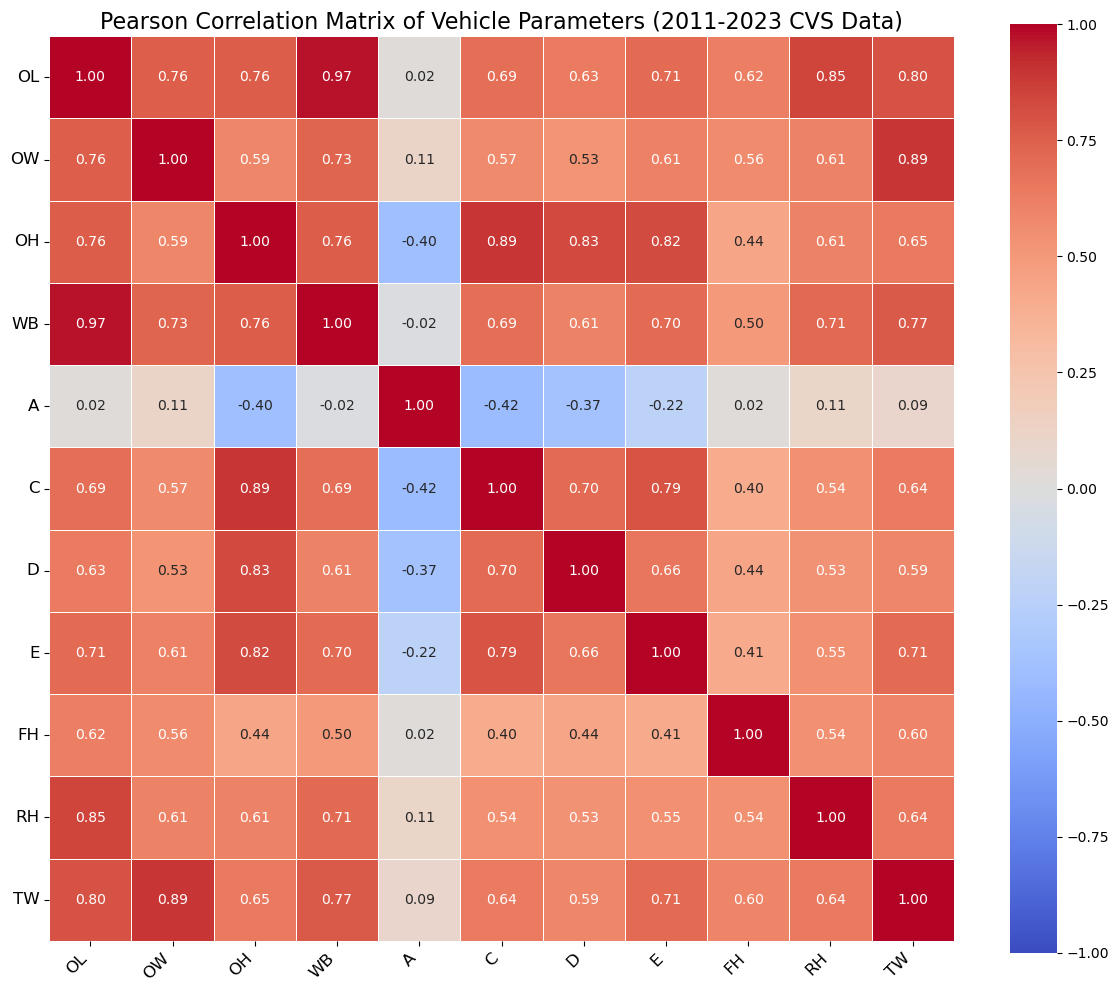

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))  # Adjust size for poster printing (e.g., make larger for high-res export)
sns.heatmap(out_df, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5, square=True)
plt.title('Pearson Correlation Matrix of Vehicle Parameters (2011-2023 CVS Data)', fontsize=16)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(rotation=0, fontsize=12)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300)  # Export high-res for poster
plt.show()

In [17]:
def estimate_ab(a_part, b_part, df):
    ab = a_part + b_part
    sdf = df[df[ab].notna().all(axis=1)][ab]
    mu_a = np.mean(sdf[a_part].values, 0)
    mu_b = np.mean(sdf[b_part].values, 0)
    cov_all = np.cov(sdf.values.T)
    cov_aa = cov_all[:len(a_part), :len(a_part)]
    cov_bb = cov_all[len(a_part):, len(a_part):]
    cov_bb_inv = np.linalg.inv(cov_bb)
    cov_ab = cov_all[:len(a_part), len(a_part):]
    pred = mu_a + ((sdf[b_part].values - mu_b) @ cov_bb_inv.T) @ cov_ab.T
    # for i in range(len(a_part)):
    #     print(a_part[i])
    #     error = np.sum(abs(pred[:, i] - sdf[a_part].values[:, i])) / pred.shape[0]
    #     print('Error', round(error, 3))
    return mu_a, cov_ab, cov_bb_inv, mu_b

In [18]:
def predict_a_from_b(b_vector, mu_a, cov_ab, cov_bb_inv, mu_b):
    diff = b_vector - mu_b
    # print(mu_a.shape, cov_ab.shape, cov_bb_inv.shape, diff.shape)  # Debug shapes
    predicted = mu_a + cov_ab @ cov_bb_inv @ diff
    print('Predicted values:', predicted)
    return predicted

In [19]:
# Save Gaussian model parameters
def save_gaussian_model(filename, mu_a, cov_ab, cov_bb_inv, mu_b, a_part, b_part):
    np.savez(filename, mu_a=mu_a, cov_ab=cov_ab, cov_bb_inv=cov_bb_inv, mu_b=mu_b,
             a_part=np.array(a_part, dtype=object), b_part=np.array(b_part, dtype=object))

# Load Gaussian model parameters
def load_gaussian_model(filename):
    data = np.load(filename, allow_pickle=True)
    return (data['mu_a'], data['cov_ab'], data['cov_bb_inv'], data['mu_b'],
            data['a_part'].tolist(), data['b_part'].tolist())

In [20]:
scenarios = [
    [['A', 'C', 'D', 'E', 'FH', 'RH', 'TW'], ['OW', 'WB']],
    [['A', 'C', 'D', 'E', 'FH', 'RH', 'TW'], ['OW', 'WB', 'OH', 'OL']]
]


In [21]:
# Compute and save models for both scenarios
car_model_param = {}
for a_part, b_part in scenarios:
    s_name = f"{'_'.join(a_part)}__{'_'.join(b_part)}"
    print(f"Training model for {s_name}")
    mu_a, cov_ab, cov_bb_inv, mu_b = estimate_ab(a_part, b_part, df)
    car_model_param[s_name] = [mu_a, cov_ab, cov_bb_inv, mu_b]
    save_gaussian_model(f'gaussian_model_{"_".join(b_part)}.npz', mu_a, cov_ab, cov_bb_inv, mu_b, a_part, b_part)
    print("---")

Training model for A_C_D_E_FH_RH_TW__OW_WB
---
Training model for A_C_D_E_FH_RH_TW__OW_WB_OH_OL
---


In [22]:
from sklearn.model_selection import train_test_split

# Split data into train (80%) and test (20%)
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

# Evaluate each scenario
for a_part, b_part in scenarios:
    print(f"Training model using {b_part}")
    
    # Train on train_df
    mu_a, cov_ab, cov_bb_inv, mu_b = estimate_ab(a_part, b_part, train_df)
    
    # Filter test_df for non-NaN values
    ab = a_part + b_part
    valid_test_df = test_df[test_df[ab].notna().all(axis=1)]

    # Predict on test_df
    pred = mu_a + ((valid_test_df[b_part].values - mu_b) @ cov_bb_inv.T @ cov_ab.T)
    
    # Compute test errors
    for i in range(len(a_part)):
        print(a_part[i])
        error = np.sum(abs(pred[:, i] - valid_test_df[a_part].values[:, i])) / pred.shape[0]
        print('Error for test data:', round(error, 3))
    print("---")

Training model using ['OW', 'WB']
A
Error for test data: 14.107
C
Error for test data: 4.388
D
Error for test data: 5.132
E
Error for test data: 8.502
FH
Error for test data: 5.066
RH
Error for test data: 9.806
TW
Error for test data: 2.221
---
Training model using ['OW', 'WB', 'OH', 'OL']
A
Error for test data: 10.544
C
Error for test data: 2.477
D
Error for test data: 3.44
E
Error for test data: 6.719
FH
Error for test data: 4.079
RH
Error for test data: 4.119
TW
Error for test data: 2.2
---
